# This code analyzes the data programming technologies used in China and US.
- The Chinese raw data is taken from `firm_data_programming`
- The US data is taken from `hot_tech_scrape`

In [1]:
import os
import pandas as pd
import gc
import numpy as np

### Get the Chinese data

In [5]:
# read and append all the csv files in folder 'G:\Data\job_post_mapping2' to one dataframe named 'dfPosting'

# define the directory
directory = 'G:/Data/job_posting_mapping2/'

# define a list to store DataFrames
dfs = []

# iterate over all files in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):  # check if the file is a csv
        # construct full file path
        file_path = os.path.join(directory, filename)
        # read the csv file and append it to the dfs list
        dfs.append(pd.read_csv(file_path))

# concatenate all DataFrames in the list
dfPosting = pd.concat(dfs, ignore_index=True)

# print the dataframe
print(dfPosting)

             招聘主键ID       公司ID        发布日期            工作名称  predicted_soc_code
0            133574  160653372  2018-12-18     人事文员长白班五险一金              434150
1            133575   68152903  2018-12-19     招聘专员/高级招聘专员              131070
2            133576  175185856  2018-12-18           资产管理员              119010
3            133577   57572702  2018-12-18            行政人事              131070
4            133578   43730331  2018-12-18       人力资源专员/助理              113120
...             ...        ...         ...             ...                 ...
99315436  110327928   40642503  2018-06-29  保险培训师、央企诚招培训讲师              259030
99315437  110327930   48482812  2018-06-29          人力资源总监              113120
99315438  110327931   34459898  2018-06-29   行政专员(纯文职，可实习)              436010
99315439  110327932   56272790  2018-06-29      中国人寿售后服务专员              434050
99315440  110327933    1013142  2018-06-29          理财管理主管              113030

[99315441 rows x 5 columns]


In [6]:
# keep year-month only in the column '发布日期'
dfPosting['发布日期'] = dfPosting['发布日期'].str[:7]

# calculate frequency distribution
freq_dist = dfPosting['发布日期'].value_counts()

# print the frequency distribution
print(freq_dist)

# number of unique values in the column '发布日期' within each year

# Create a new column that contains the year of each release date
dfPosting['year'] = dfPosting['发布日期'].str[:4]

# Group the DataFrame by year and count the number of unique release dates in each group
result = dfPosting.groupby('year')['发布日期'].nunique()

# Print the result
print(result)

# drop if 'year' is 2016 or 2021
dfPosting = dfPosting[dfPosting['year'] != '2020']
dfPosting = dfPosting[dfPosting['year'] != '2021']

# convert the column '发布日期' to quarterly
dfPosting['发布日期'] = pd.to_datetime(dfPosting['发布日期'])
dfPosting['发布日期'] = dfPosting['发布日期'].dt.to_period('Q')

# drop column '工作名称' 
dfPosting.drop(['工作名称', '公司ID'], axis=1, inplace=True)

# rename 'predicted_soc_code' as 'soc_code'
dfPosting.rename(columns={'predicted_soc_code': 'soc_code'}, inplace=True)

发布日期
2017-03    5898254
2018-07    4553896
2017-02    3735209
2017-06    3514919
2017-05    3241251
            ...   
2021-05     210628
2016-10     180696
2016-05     119262
2021-08       6073
2016-11         86
Name: count, Length: 64, dtype: int64
year
2016     8
2017    12
2018    12
2019    12
2020    12
2021     8
Name: 发布日期, dtype: int64


In [7]:
# The `data programming tech` indicator is create from keywords_preparing.ipynb.
dfProgram = pd.read_csv('G:/Data/job_posting/processed/estimation/posting_dataprogfull.csv', encoding='utf-8')

# merge 'dfProgram' with 'dfPosting' on '招聘主键ID', keep matched sample only
dfPosting = pd.merge(dfPosting, dfProgram, on='招聘主键ID', how='inner')

# generate column 'posting_count` with all values equal to 1
dfPosting['posting_count'] = 1

# Perform the collapse by 'soc_code' and sum the values from columns 6 to 57
columns_to_sum = dfPosting.columns[5:58]
dfPosting_collapse = dfPosting.groupby('soc_code')[columns_to_sum].sum()

# Reset the index for better readability
dfPosting_collapse.reset_index(inplace=True)

# Divide the values from columns 2 to 52 by the values in the 'posting_count' column
dfPosting_collapse.iloc[:, 1:53] = dfPosting_collapse.iloc[:, 1:53].div(dfPosting_collapse['posting_count'], axis=0)

# multiply values from columns 2 to 52 by 100
dfPosting_collapse.iloc[:, 1:53] = dfPosting_collapse.iloc[:, 1:53].mul(100)

# Drop the 'posting_count' column
dfPosting_collapse.drop(columns=['posting_count'], inplace=True)

# Reshape the DataFrame from wide to long format using pandas' melt function
dfPosting_collapse_long = pd.melt(dfPosting_collapse, id_vars=['soc_code'], var_name='Commodity Title', value_name='Percentage')

# Display the first few rows of the reshaped DataFrame
dfPosting_collapse_long.head()

## Due to the sample size is too late for local computer's memory (128G), we move the above code to `HPC`.
- Now, load the file after the calculation is done.

In [2]:
# load the dataframe back
dfPosting_collapse_long = pd.read_csv('G:/Data/job_posting/processed/estimation/dfPosting_collapse_long.csv', encoding='utf-8')
dfPosting_collapse_long

,soc_code,Commodity Title,Percentage
0,111010,data_software,0.795725
1,111020,data_software,0.810703
2,111030,data_software,1.577537
3,112010,data_software,1.260265
4,112020,data_software,0.815271
...,...,...,...
20701,537060,Web platform development software_China_0,0.046728
20702,537070,Web platform development software_China_0,0.301318
20703,537080,Web platform development software_China_0,0.367422
20704,537120,Web platform development software_China_0,0.412107


#### Get the frequency within each commodity type to normalize the aggregated Chinese data

In [3]:
# read a csv file (includes both Chinese and English characteristics) from 'E:/Data/job_posting/processed/title_short.csv' 
key_df = pd.read_excel('G:/Data/job_posting/processed/title_short.xlsx')
# Generating a new column to represent the combination of 'Commodity Title' and 'Safe'
key_df['Commodity_Safe'] = key_df['Commodity Title'] +  '_' + 'Safe'+  '_' + key_df['Safe'].astype(str)
# Generating a new column to represent the combination of 'Commodity Title' and 'China'
key_df['Commodity_China'] = key_df['Commodity Title'] +  '_' + 'China' + '_' + key_df['China'].astype(str)
# generate column 'progCount' to count the unique values of 'Software' within each 'Commodity Title' 
key_df['progCount_Safe'] = key_df.groupby('Commodity_Safe')['Example'].transform('nunique')
key_df['progCount_China'] = key_df.groupby('Commodity_China')['Example'].transform('nunique')
# keep columns 'Commodity Title' and 'progCount' only
key_df = key_df[['Commodity_Safe', 'Commodity_China', 'progCount_Safe', 'progCount_China']]

# Create subsample for 'Safe'
safe_subsample = key_df[['Commodity_Safe', 'progCount_Safe']].copy()
safe_subsample.columns = ['Commodity Title', 'progCount']

# Create subsample for 'China'
china_subsample = key_df[['Commodity_China', 'progCount_China']].copy()
china_subsample.columns = ['Commodity Title', 'progCount']

# Append the two subsamples
key_df = pd.concat([safe_subsample, china_subsample], ignore_index=True)

# Check for duplicate rows in the reshaped dataframe
duplicate_rows = key_df.duplicated(subset=['Commodity Title'], keep=False)
duplicates = key_df[duplicate_rows].sort_values(by=['Commodity Title']) if duplicate_rows.any() else None

# Drop duplicate rows from the reshaped dataframe
key_df.drop_duplicates(subset=['Commodity Title'], keep='first', inplace=True)

# Display the updated reshaped dataframe
key_df.reset_index(drop=True, inplace=True)

key_df.head()

,Commodity Title,progCount
0,Accounting software_Safe_0,1
1,Accounting software_Safe_1,1
2,Analytical or scientific software_Safe_0,3
3,Business intelligence and data analysis softwa...,1
4,Business intelligence and data analysis softwa...,3


In [4]:
# merge df with key_df on 'Tech', keep matched rows
dfPosting_collapse_long = pd.merge(dfPosting_collapse_long, key_df, on='Commodity Title', how='left')

# replace null in 'progCount' with 1 if 'Commdoity Title' is 'data_software'
dfPosting_collapse_long.loc[(dfPosting_collapse_long['Commodity Title'] == 'data_software') & (dfPosting_collapse_long['progCount'].isnull()), 'progCount'] = 1

# rename column 'Percentage' to 'PercentageSum' 
dfPosting_collapse_long.rename(columns={'Percentage': 'PercentageSum'}, inplace=True)

# normalize the column 'Percentage' by 'progCount'
dfPosting_collapse_long['Percentage'] = dfPosting_collapse_long['PercentageSum'] / dfPosting_collapse_long['progCount']
# remove column 'progCount'
dfPosting_collapse_long = dfPosting_collapse_long.drop(columns=['progCount'])
# sort by 'soc_code' and 'Commodity Title'
dfPosting_collapse_long = dfPosting_collapse_long.sort_values(by=['soc_code', 'Commodity Title'])
# rename column 'Percentage' to 'PercentageCN' 
dfPosting_collapse_long.rename(columns={'Percentage': 'PercentageCN', 'PercentageSum': 'PercentageSumCN'}, inplace=True)
dfPosting_collapse_long.head(5)

,soc_code,Commodity Title,PercentageSumCN,PercentageCN
11774,111010,Accounting software_China_0,0.000484,0.000484
12180,111010,Accounting software_China_1,0.002419,0.002419
406,111010,Accounting software_Safe_0,0.000484,0.000484
812,111010,Accounting software_Safe_1,0.002419,0.002419
12586,111010,Analytical or scientific software_China_0,0.036956,0.012319


In [5]:
# Random Check: keep if 'Commodity Title' is 'Analytical or scientific software_China_0' 
# Filter the DataFrame to keep only the rows where 'Commodity Title' is 'Analytical or scientific software_China_0'
filtered_df = dfPosting_collapse_long[dfPosting_collapse_long['Commodity Title'] == 'Analytical or scientific software_China_0']
sorted_df = filtered_df.sort_values(by='PercentageSumCN')
# sort by PercentageSumCN
sorted_df.tail(10)

,soc_code,Commodity Title,PercentageSumCN,PercentageCN
12688,194060,Analytical or scientific software_China_0,3.784886,1.261629
12678,193010,Analytical or scientific software_China_0,4.579580,1.526527
12682,193090,Analytical or scientific software_China_0,7.137523,2.379174
12680,193030,Analytical or scientific software_China_0,12.007581,4.002527
12645,152030,Analytical or scientific software_China_0,12.437163,4.145721
12644,152020,Analytical or scientific software_China_0,15.096322,5.032107
12647,152050,Analytical or scientific software_China_0,15.325035,5.108345
12679,193020,Analytical or scientific software_China_0,15.531361,5.177120
12646,152040,Analytical or scientific software_China_0,23.155716,7.718572
12648,152090,Analytical or scientific software_China_0,30.856941,10.285647


### Analyze the Chinese data
- we limit commodity types to the ones with softwares developed in China. There are 6 commodity types in total.
- we are interested in the share of Chinese softwares in each commodity type.
- to make the figure readable, we aggregate the occupation to 4 digit level.

In [6]:
# Extract the software type and origin information from 'Commodity Title' into new columns
dfPosting_collapse_long['Software Type'] = dfPosting_collapse_long['Commodity Title'].str.extract(r'(.+)_[^_]+_[^_]+$')
dfPosting_collapse_long['Origin'] = dfPosting_collapse_long['Commodity Title'].str.extract(r'_[^_]+_([^_]+)$')

# Debug: Check unique software types that are developed in China (indicated by 'China_1') within each 'soc_code'
china_software_types = dfPosting_collapse_long[dfPosting_collapse_long['Commodity Title'].str.endswith('China_1')].groupby('soc_code')['Software Type'].nunique().reset_index()
china_software_types.rename(columns={'Software Type': 'Unique Software Types in China'}, inplace=True)

# Filter out the rows corresponding to software developed in China (indicated by 'China_1')
df_china = dfPosting_collapse_long[dfPosting_collapse_long['Commodity Title'].str.endswith('China_1')]

# Filter out the rows corresponding to all software regardless of being developed in China or not (indicated by 'China_0' and 'China_1')
df_all_china = dfPosting_collapse_long[dfPosting_collapse_long['Commodity Title'].str.contains('China_')]
df_all_china

,soc_code,Commodity Title,PercentageSumCN,PercentageCN,Software Type,Origin
11774,111010,Accounting software_China_0,0.000484,0.000484,Accounting software,0
12180,111010,Accounting software_China_1,0.002419,0.002419,Accounting software,1
12586,111010,Analytical or scientific software_China_0,0.036956,0.012319,Analytical or scientific software,0
12992,111010,Business intelligence and data analysis softwa...,0.015963,0.003991,Business intelligence and data analysis software,0
13398,111010,Computer aided design CAD software_China_0,0.154985,0.077493,Computer aided design CAD software,0
...,...,...,...,...,...,...
19081,537190,Metadata management software_China_0,0.000000,0.000000,Metadata management software,0
19487,537190,Object or component oriented development softw...,0.482142,0.048214,Object or component oriented development software,0
19893,537190,Object oriented data base management software_...,0.047147,0.015716,Object oriented data base management software,0
20299,537190,Program testing software_China_0,0.006227,0.003113,Program testing software,0


In [7]:
# Extract the software type and origin information from 'Commodity Title' into new columns
dfPosting_collapse_long['Software Type'] = dfPosting_collapse_long['Commodity Title'].str.extract(r'(.+)_[^_]+_[^_]+$')
dfPosting_collapse_long['Origin'] = dfPosting_collapse_long['Commodity Title'].str.extract(r'_[^_]+_([^_]+)$')

# Debug: Check unique software types that are developed in China (indicated by 'China_1') within each 'soc_code'
china_software_types = dfPosting_collapse_long[dfPosting_collapse_long['Commodity Title'].str.endswith('China_1')].groupby('soc_code')['Software Type'].nunique().reset_index()
china_software_types.rename(columns={'Software Type': 'Unique Software Types in China'}, inplace=True)

# Filter out the rows corresponding to software developed in China (indicated by 'China_1')
df_china = dfPosting_collapse_long[dfPosting_collapse_long['Commodity Title'].str.endswith('China_1')]

# Filter out the rows corresponding to all software regardless of being developed in China or not (indicated by 'China_0' and 'China_1')
df_all_china = dfPosting_collapse_long[dfPosting_collapse_long['Commodity Title'].str.contains('China_')]

# Sum 'PercentageSumCN' grouped by 'soc_code' and 'Software Type' for software developed in China and all software
china_sum = df_china.groupby(['soc_code', 'Software Type'])['PercentageSumCN'].sum().reset_index()
all_sum = df_all_china.groupby(['soc_code', 'Software Type'])['PercentageSumCN'].sum().reset_index()

# Merge the two summed dataframes on 'soc_code' and 'Software Type'
shareChina_df = pd.merge(china_sum, all_sum, on=['soc_code', 'Software Type'], suffixes=('_China', '_All'))

# Calculate the share of software that is developed in China
shareChina_df['China_Share'] = shareChina_df['PercentageSumCN_China'] / shareChina_df['PercentageSumCN_All']

# Show the first few rows of the new dataframe
shareChina_df.head(10)

,soc_code,Software Type,PercentageSumCN_China,PercentageSumCN_All,China_Share
0,111010,Accounting software,0.002419,0.002902,0.833333
1,111010,Computer aided design CAD software,0.000193,0.155179,0.001247
2,111010,Data base management system software,0.000000,0.062497,0.000000
3,111010,Data base user interface and query software,0.014125,0.110966,0.127289
4,111010,Enterprise resource planning ERP software,0.087457,0.126832,0.689550
5,111010,Medical software,0.003580,0.003580,1.000000
6,111020,Accounting software,0.002210,0.002210,1.000000
7,111020,Computer aided design CAD software,0.000442,0.107404,0.004115
8,111020,Data base management system software,0.000177,0.042520,0.004158
9,111020,Data base user interface and query software,0.009547,0.123493,0.077309


#### This figure indicates:
- the share of Chinese softwares across commodity type varies.
- the share is higher in business/ industry specific software classes. The share is low in data management and development software classes.

C:\Users\DELL\AppData\Local\Temp\ipykernel_6432\910164196.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shareChina_df1['soc_code'] = shareChina_df1['soc_code'].astype(str)
C:\Users\DELL\AppData\Local\Temp\ipykernel_6432\910164196.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shareChina_df1['soc_code_4_digits'] = shareChina_df1['soc_code'].str[:5]


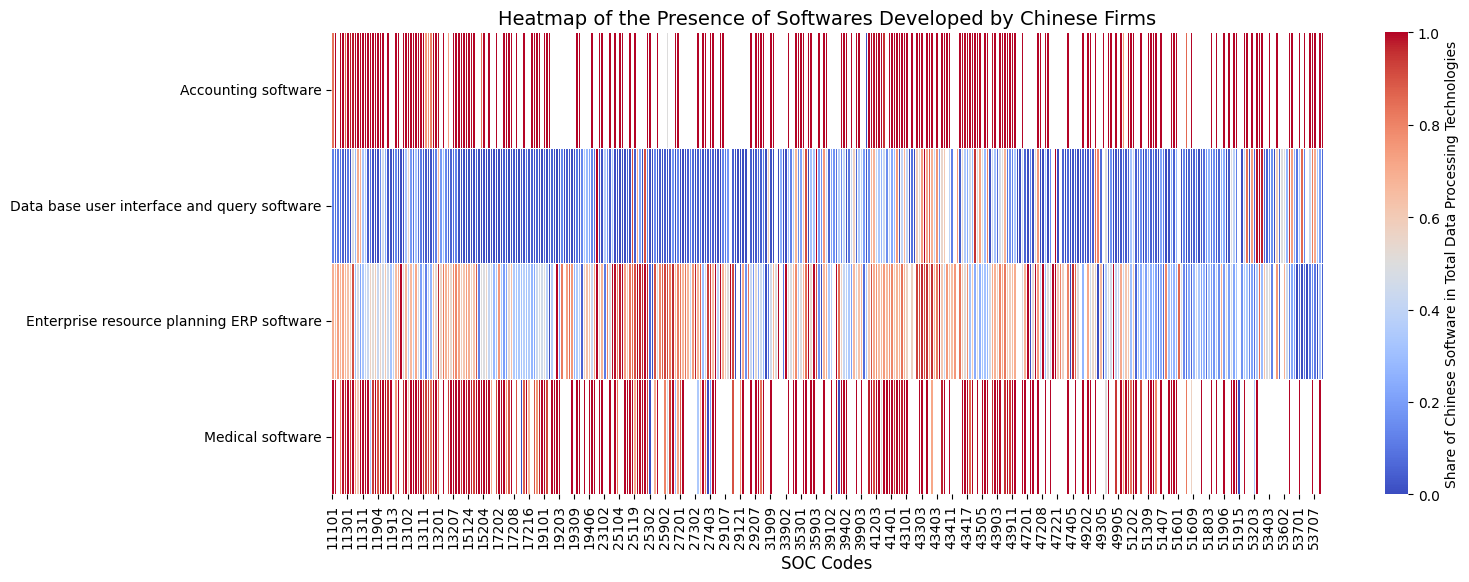

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# remove if software type is 'Computer aided design CAD software' or 'Data base management system software' 
shareChina_df1 = shareChina_df[~shareChina_df['Software Type'].isin(['Computer aided design CAD software', 'Data base management system software'])]

# Convert 'soc_code' to string type for string slicing operations
shareChina_df1['soc_code'] = shareChina_df1['soc_code'].astype(str)

# Create a new column that takes the first 4 digits of 'soc_code' for less granular classification
shareChina_df1['soc_code_4_digits'] = shareChina_df1['soc_code'].str[:5]

# Replace the last digit of 'soc_code_4_digits' to '0' 
#shareChina_df['soc_code_4_digits'] = shareChina_df['soc_code_4_digits'].str[:4] + '0'

# Aggregate data at the new 'soc_code_4_digits' and 'Software Type' level, taking the mean of 'China_Share'
# Use mean() function which by default ignores NaN values for safe aggregation
heatmap_data_aggregated = shareChina_df1.groupby(['soc_code_4_digits', 'Software Type'])['China_Share'].mean().reset_index()

# Create a pivot table for the heatmap
heatmap_data_pivot = heatmap_data_aggregated.pivot_table(values='China_Share', index='Software Type', columns='soc_code_4_digits')

# Proceed with the suggested improvements, excluding the missing_data_color

# 1. Color Scheme: Use a diverging color scheme to highlight extreme values.
# 2. Annotations: Limit annotations to significant values, for demonstration let's annotate only values greater than 0.2.
# 3. Size and Aspect Ratio: Adjust figure size for readability.
# 4. Axis Labels and Titles: Make them clear and descriptive.

# Plot the improved heatmap
plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data_pivot, annot=False, cmap="coolwarm", cbar=True, linewidths=.5, 
            cbar_kws={'label': 'Share of Chinese Software in Total Data Processing Technologies'},
            mask=heatmap_data_pivot.isnull())

# Add labels and titles
plt.title('Heatmap of the Presence of Softwares Developed by Chinese Firms', fontsize=14)
plt.xlabel('SOC Codes', fontsize=12)
plt.ylabel('', fontsize=12)

plt.show()

## Get the frequency of the data programming for `US` data.
- Note we impute 0.5% for 'Under 1%' in the percentage column (see the raw data of percentage: https://www.onetonline.org/search/hot_tech/example?e=Microsoft%20Excel), and impute 0 for 'Not available' in the percentage column.

In [8]:
# read a csv file (includes both Chinese and English characteristics) from 'E:/Data/job_posting/processed/title_short.csv' 
key_df = pd.read_excel('G:/Data/job_posting/processed/title_short.xlsx')
# Generating a new column to represent the combination of 'Commodity Title' and 'Safe'
key_df['Commodity_Safe'] = key_df['Commodity Title'] +  '_' + 'Safe'+  '_' + key_df['Safe'].astype(str)
# Generating a new column to represent the combination of 'Commodity Title' and 'China'
key_df['Commodity_China'] = key_df['Commodity Title'] +  '_' + 'China' + '_' + key_df['China'].astype(str)
# rename column 'Example' to 'Tech'
key_df.rename(columns={'Example': 'Tech'}, inplace=True)
key_df


,Commodity Title,Tech,Example_short,Safe,China,Commodity_Safe,Commodity_China
0,Accounting software,Intuit QuickBooks,QuickBooks,0,0,Accounting software_Safe_0,Accounting software_China_0
1,Accounting software,速达软件,速达,1,1,Accounting software_Safe_1,Accounting software_China_1
2,Analytical or scientific software,IBM SPSS Statistics,SPSS,0,0,Analytical or scientific software_Safe_0,Analytical or scientific software_China_0
3,Analytical or scientific software,SAS,SAS,0,0,Analytical or scientific software_Safe_0,Analytical or scientific software_China_0
4,Analytical or scientific software,The MathWorks MATLAB,MATLAB,0,0,Analytical or scientific software_Safe_0,Analytical or scientific software_China_0
...,...,...,...,...,...,...,...
81,Web platform development software,Oracle JavaServer Pages JSP,JSP,0,0,Web platform development software_Safe_0,Web platform development software_China_0
82,Web platform development software,PHP,PHP,1,0,Web platform development software_Safe_1,Web platform development software_China_0
83,Web platform development software,React,React,1,0,Web platform development software_Safe_1,Web platform development software_China_0
84,Web platform development software,Ruby on Rails,Rails,1,0,Web platform development software_Safe_1,Web platform development software_China_0


In [9]:
# read a csv file (includes both Chinese and English characteristics) from 'E:/Data/job_posting/processed/title_short.csv' 
key_df = pd.read_excel('G:/Data/job_posting/processed/title_short.xlsx')
# Generating a new column to represent the combination of 'Commodity Title' and 'Safe'
key_df['Commodity_Safe'] = key_df['Commodity Title'] +  '_' + 'Safe'+  '_' + key_df['Safe'].astype(str)
# Generating a new column to represent the combination of 'Commodity Title' and 'China'
key_df['Commodity_China'] = key_df['Commodity Title'] +  '_' + 'China' + '_' + key_df['China'].astype(str)
# rename column 'Example' to 'Tech'
key_df.rename(columns={'Example': 'Tech'}, inplace=True)
key_df.head(5)

df = pd.read_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/technology_skill_onet/tech_used_states.csv')
# `Percentage` represents the ratio of unique postings which mention the skill to all unique postings linked to the O*NET-SOC occupation.
# sort by 'Occupation' 
df = df.sort_values(by=['Occupation'])
# replace 'Percentage' to '0.5' if 'Percentage' is 0
df.loc[(df['Percentage'] == 0), 'Percentage'] = 0.5
# replace 'NaN' to 0 in 'Percentage' column, replace 'NaN' to 'No' in 'In Demand' column 
df['Percentage'] = df['Percentage'].fillna(0)
df['In Demand'] = df['In Demand'].fillna('No')
df.head(5)

# merge df with key_df on 'Tech', keep matched rows
merged_df = pd.merge(df, key_df, on='Tech', how='inner')
# generate column 'progCount' to count the unique values of 'Software' within each 'Commodity Title' 
merged_df['progCount_Safe'] = merged_df.groupby('Commodity_Safe')['Tech'].transform('nunique')
merged_df['progCount_China'] = merged_df.groupby('Commodity_China')['Tech'].transform('nunique')
merged_df.head(5)

,Percentage,Job Zone,Code,Occupation,In Demand,Tech,Commodity Title,Example_short,Safe,China,Commodity_Safe,Commodity_China,progCount_Safe,progCount_China
0,0.5,4,13-2011.00,Accountants and Auditors,No,Microsoft Visual Basic for Applications VBA,Development environment software,VBA,0,0,Development environment software_Safe_0,Development environment software_China_0,5,11
1,2.0,4,13-2011.00,Accountants and Auditors,No,Microsoft Access,Data base user interface and query software,Access,0,0,Data base user interface and query software_Sa...,Data base user interface and query software_Ch...,6,7
2,5.0,4,13-2011.00,Accountants and Auditors,Yes,SAP software,Enterprise resource planning ERP software,SAP,0,0,Enterprise resource planning ERP software_Safe_0,Enterprise resource planning ERP software_China_0,2,2
3,6.0,4,13-2011.00,Accountants and Auditors,Yes,Intuit QuickBooks,Accounting software,QuickBooks,0,0,Accounting software_Safe_0,Accounting software_China_0,1,1
4,0.0,4,13-2011.00,Accountants and Auditors,No,Epic Systems,Medical software,Epic,0,0,Medical software_Safe_0,Medical software_China_0,1,1


In [10]:
# collapse rows by 'Code', and 'Commodity Title', sum 'Percentage' and average 'progCount'
# This is because commodity title includes multiple techs, and we want to sum the percentage of each tech within each commodity title
merged_df1 = merged_df.groupby(['Code', 'Commodity_Safe']).agg({'Percentage': 'sum', 'progCount_Safe': 'mean'}).reset_index()
merged_df2 = merged_df.groupby(['Code', 'Commodity_China']).agg({'Percentage': 'sum', 'progCount_China': 'mean'}).reset_index()

# Create subsample for 'Safe'
safe_subsample = merged_df1[['Commodity_Safe', 'progCount_Safe', 'Percentage', 'Code']].copy()
safe_subsample.columns = ['Commodity Title', 'progCount', 'Percentage', 'Code']

# Create subsample for 'China'
china_subsample = merged_df2[['Commodity_China', 'progCount_China', 'Percentage', 'Code']].copy()
china_subsample.columns = ['Commodity Title', 'progCount', 'Percentage', 'Code']
# Append the two subsamples
merged_df3 = pd.concat([safe_subsample, china_subsample], ignore_index=True)
# sort by 'Code' and 'Commodity Title'
merged_df3 = merged_df3.sort_values(by=['Code', 'Commodity Title'])
merged_df3.head(5)

,Commodity Title,progCount,Percentage,Code
2210,Accounting software_China_0,1.0,0.5,11-1011.00
0,Accounting software_Safe_0,1.0,0.5,11-1011.00
2211,Data base user interface and query software_Ch...,7.0,0.5,11-1011.00
1,Data base user interface and query software_Sa...,6.0,0.5,11-1011.00
2212,Enterprise application integration software_Ch...,3.0,0.0,11-1011.00


In [11]:
# rename column 'Percentage' to 'PercentageSum' 
merged_df3.rename(columns={'Percentage': 'PercentageSum'}, inplace=True)
# normalize the column 'Percentage' by 'progCount'
merged_df3['Percentage'] = merged_df3['PercentageSum'] / merged_df3['progCount']
# remove column 'progCount'
merged_df3 = merged_df3.drop(columns=['progCount'])
# export 'merged_df3' for the use of generating shift-share IV
merged_df3.to_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/dfPosting_shiftshare.csv', index=False, encoding='utf-8-sig')

# sort by 'soc_code' and 'Commodity Title'
merged_df3 = merged_df3.sort_values(by=['Code', 'Commodity Title'])
# keep first 7 characters in 'Code' column
merged_df3['soc_code'] = merged_df3['Code'].str[:7]
# remove '-' in column 'soc_code' 
merged_df3['soc_code'] = merged_df3['soc_code'].str.replace('-', '')
# replace the last digit in column 'soc_code' to be 0
merged_df3['soc_code'] = merged_df3['soc_code'].str[:-1] + '0'
# collapse rows by 'soc_code'and 'Commodity Title', average 'Percentage'
merged_df3 = merged_df3.groupby(['soc_code', 'Commodity Title']).agg({'Percentage': 'mean', 'PercentageSum': 'mean'}).reset_index()

# rename column 'Percentage' to 'PercentageUS'
merged_df3.rename(columns={'Percentage': 'PercentageUS', 'PercentageSum': 'PercentageSumUS'}, inplace=True)
# convert data type of column 'soc_code' to int64
merged_df3['soc_code'] = merged_df3['soc_code'].astype('int64')
merged_df3.head(20)

,soc_code,Commodity Title,PercentageUS,PercentageSumUS
0,111010,Accounting software_China_0,0.500000,0.50
1,111010,Accounting software_Safe_0,0.500000,0.50
2,111010,Business intelligence and data analysis softwa...,0.750000,3.00
3,111010,Business intelligence and data analysis softwa...,1.000000,3.00
4,111010,Data base user interface and query software_Ch...,0.035714,0.25
5,111010,Data base user interface and query software_Sa...,0.041667,0.25
6,111010,Enterprise application integration software_Ch...,0.000000,0.00
7,111010,Enterprise application integration software_Sa...,0.000000,0.00
8,111010,Enterprise resource planning ERP software_China_0,0.125000,0.25
9,111010,Enterprise resource planning ERP software_Safe_0,0.125000,0.25


## Merge and analysis the data programming in China and US
- Note: after the merge number of observation has been dropped significantly, this is because less obs is included in the US data.

In [ ]:
# merge 'dfPosting_collapse_long' with 'merged_df' on 'soc_code' and 'Commodity Title', keep matched rows
dfPosting_comp = pd.merge(dfPosting_collapse_long, merged_df3, on=['soc_code', 'Commodity Title'], how='inner')
print(dfPosting_comp.shape)
dfPosting_comp.head(5)
# export dfPosting_comp' to 'C:\Users\DELL\Desktop'
dfPosting_comp.to_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/dfPosting_comp.csv', index=False, encoding='utf-8-sig')
# load dataframe 'dfPosting_comp' from 'C:/Users/DELL/Desktop/dfPosting_comp.csv'
dfPosting_comp = pd.read_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/dfPosting_comp.csv', encoding='utf-8-sig')

(2507, 8)


,soc_code,Commodity Title,PercentageSumCN,PercentageCN,Software Type,Origin,PercentageUS,PercentageSumUS
0,111010,Accounting software_China_0,0.000484,0.000484,Accounting software,0,0.500000,0.50
1,111010,Accounting software_Safe_0,0.000484,0.000484,Accounting software,0,0.500000,0.50
2,111010,Business intelligence and data analysis softwa...,0.015963,0.003991,Business intelligence and data analysis software,0,0.750000,3.00
3,111010,Business intelligence and data analysis softwa...,0.001258,0.000419,Business intelligence and data analysis software,0,1.000000,3.00
4,111010,Data base user interface and query software_Ch...,0.096841,0.013834,Data base user interface and query software,0,0.035714,0.25


### Heatmap to show the correlation between the programming languages in China and US
- Under three cases: consider 3 cases: all foreign softwares, open-sourced, and properitary softwares
- A blank space means missing value
- This figure indicates the correlation is relatively high. Especially for open-sourced softwares, the correlation is higher than the other two cases.
- In addition, the data management and development software classes have higher correlation than the other classes.

C:\Users\DELL\AppData\Local\Temp\ipykernel_34116\631170898.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_corr = dfPosting_comp.groupby('Commodity Title').apply(lambda x: x['PercentageSumCN'].corr(x['PercentageSumUS']))


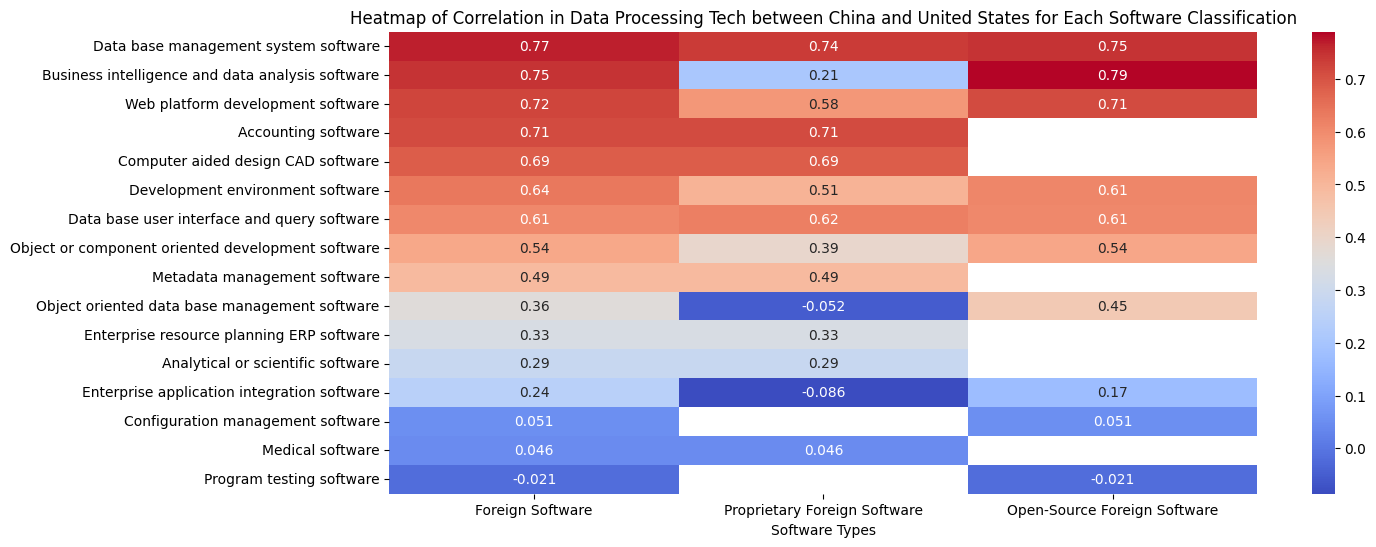

In [14]:
# Importing necessary libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# replace 'PercentageSumCN' to NaN if 'PercentageSumCN' is 0
#dfPosting_comp.loc[(dfPosting_comp['PercentageSumCN'] == 0), 'PercentageSumCN'] = np.nan
# replace 'PercentageSumUS' to NaN if 'PercentageSumUS' is 0
#dfPosting_comp.loc[(dfPosting_comp['PercentageSumUS'] == 0), 'PercentageSumUS'] = np.nan

# Calculate the overall correlation between 'PercentageSumCN' and 'PercentageSumUS'
overall_corr = dfPosting_comp['PercentageSumCN'].corr(dfPosting_comp['PercentageSumUS'])

# Calculate the correlation between 'PercentageSumCN' and 'PercentageSumUS' for each 'Commodity Title'
grouped_corr = dfPosting_comp.groupby('Commodity Title').apply(lambda x: x['PercentageSumCN'].corr(x['PercentageSumUS']))

# Filter the grouped correlation data based on the ending strings in 'Commodity Title'
grouped_corr_china = grouped_corr[grouped_corr.index.str.endswith('China_0')]
grouped_corr_safe0 = grouped_corr[grouped_corr.index.str.endswith('Safe_0')]
grouped_corr_safe1 = grouped_corr[grouped_corr.index.str.endswith('Safe_1')]

# Remove the ending strings to get a common label for each row
grouped_corr_china.index = grouped_corr_china.index.str.replace('_China_0', '')
grouped_corr_safe0.index = grouped_corr_safe0.index.str.replace('_Safe_0', '')
grouped_corr_safe1.index = grouped_corr_safe1.index.str.replace('_Safe_1', '')

# Combine these into a single DataFrame
combined_corr = pd.DataFrame({
    'China_0': grouped_corr_china,
    'Safe_0': grouped_corr_safe0,
    'Safe_1': grouped_corr_safe1
})

# Display the combined DataFrame
combined_corr.head()

# Sort the combined DataFrame based on the values in the 'China_0' column in ascending order
sorted_combined_corr = combined_corr.sort_values(by='China_0', ascending=False)

# Rename the columns as per the user's request
renamed_combined_corr = sorted_combined_corr.rename(columns={
    'China_0': 'Foreign Software',
    'Safe_0': 'Proprietary Foreign Software',
    'Safe_1': 'Open-Source Foreign Software'
})

# Generate the heatmap with the renamed and sorted data
# Adjust the figsize: increase the width and decrease the height
plt.figure(figsize=(14, 6))  # Increase the width and decrease the height as per your requirement
sns.heatmap(renamed_combined_corr, annot=True, cmap='coolwarm', cbar=True)
plt.title('Heatmap of Correlation in Data Processing Tech between China and United States for Each Software Classification')
plt.xlabel('Software Types')
plt.ylabel('')
plt.show()

### Scatter plot to show the correlation between the data programming in China and US at `occupation-commodity` group level
### At `occupation-commodity` group level, we compare the data programming in China and US
- limit the sample to percentage less than 30 (exclude the outliers)
- consider 3 cases: all foreign softwares, open-sourced, and properitary softwares
- the adoption of data programming in China is less common than Untied States

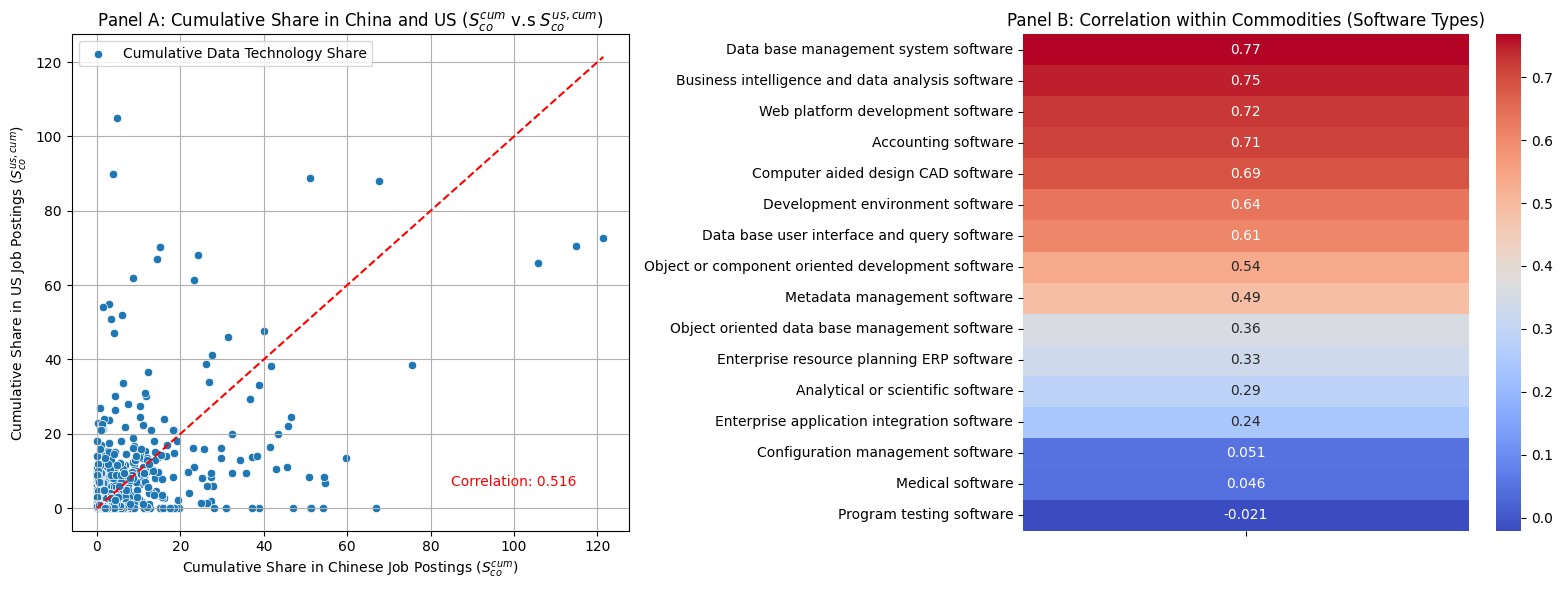

In [23]:
# Re-import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# [Your data preparation code here...]
# Rename the columns as per the user's request
renamed_combined_corr = sorted_combined_corr.rename(columns={
    'China_0': '',
    'Safe_0': 'Proprietary Foreign Software',
    'Safe_1': 'Open-Source Foreign Software'
})

# Initialize a 1x2 grid of subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Scatter Plot for the First Column ---
# Calculate the correlation for the scatter plot
original_corr = dfPosting_comp['PercentageSumCN'].corr(dfPosting_comp['PercentageSumUS'])

# Generate the scatter plot in the first subplot
sns.scatterplot(data=dfPosting_comp, x='PercentageSumCN', y='PercentageSumUS', ax=axes[0], label='Cumulative Data Technology Share')

# Add a 45-degree line for reference in the scatter plot
max_value = max(dfPosting_comp['PercentageSumCN'].max(), dfPosting_comp['PercentageSumUS'].max())
axes[0].plot([0, max_value], [0, max_value], '--', color='red', label='45-degree line')

# Add text to indicate the correlation value in the scatter plot
axes[0].text(max_value*0.7, max_value*0.05, f"Correlation: {original_corr:.3f}", fontsize=10, color='red')

# Add titles and labels to the scatter plot
axes[0].set_title('Panel A: Cumulative Share in China and US ($S_{co}^{cum}$ v.s $S_{co}^{us, cum}$)')
axes[0].set_xlabel('Cumulative Share in Chinese Job Postings ($S_{co}^{cum}$)')
axes[0].set_ylabel('Cumulative Share in US Job Postings ($S_{co}^{us, cum}$)')
axes[0].grid(True)

# --- Heatmap for the Second Column ---
# Select only the 'Foreign Software' column for the heatmap
foreign_software_corr = renamed_combined_corr[['']]

# Generate the heatmap in the second subplot
sns.heatmap(foreign_software_corr, annot=True, cmap='coolwarm', cbar=True, ax=axes[1])
axes[1].set_title('Panel B: Correlation within Commodities (Software Types)')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

# Adjust layout and display the combined plot
plt.tight_layout()
plt.show()


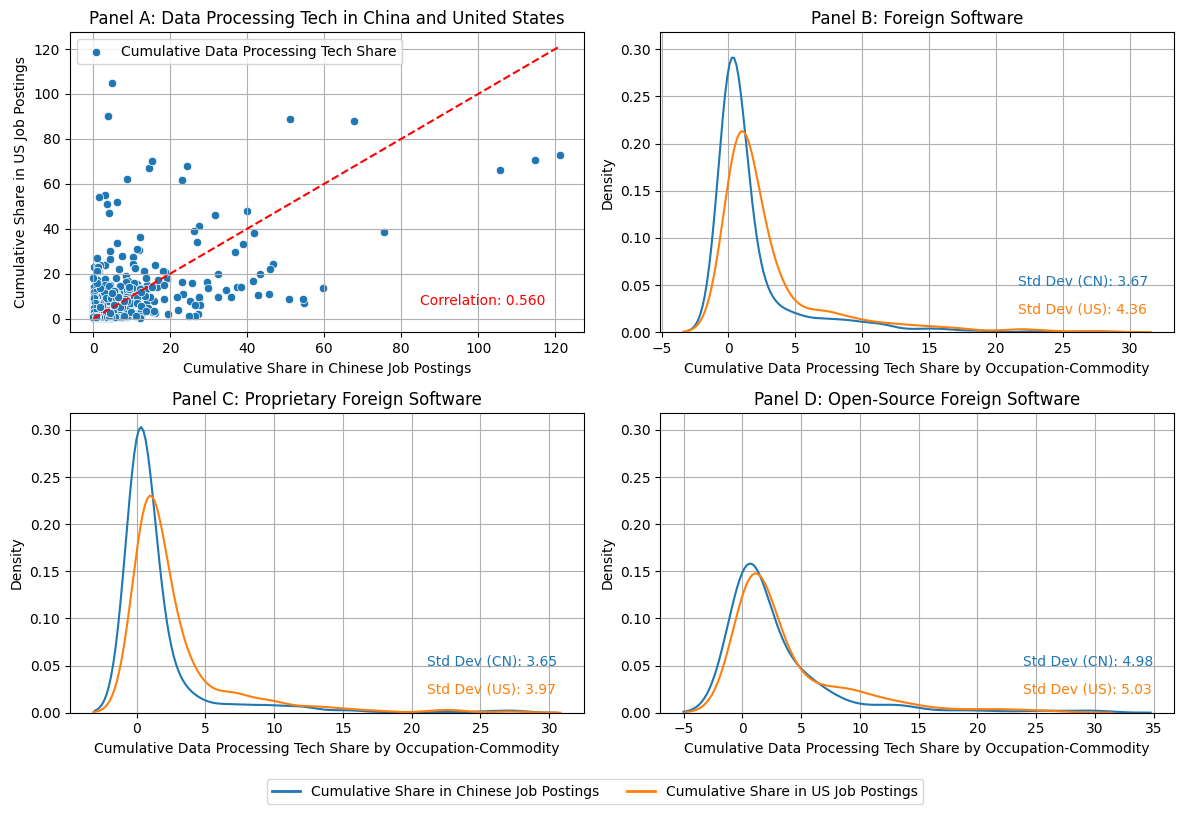

In [18]:
# Re-import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Initialize a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# --- Scatter Plot ---
# Calculate the correlation
original_corr = dfPosting_comp['PercentageSumCN'].corr(dfPosting_comp['PercentageSumUS'])

# Generate the scatter plot
sns.scatterplot(data=dfPosting_comp, x='PercentageSumCN', y='PercentageSumUS', ax=axes[0, 0], label='Cumulative Data Processing Tech Share')

# Add a 45-degree line for reference
max_value = max(dfPosting_comp['PercentageSumCN'].max(), dfPosting_comp['PercentageSumUS'].max())
line_45, = axes[0, 0].plot([0, max_value], [0, max_value], '--', color='red', label='45-degree line')

# Add text to indicate the correlation value
axes[0, 0].text(max_value*0.7, max_value*0.05, f"Correlation: {original_corr:.3f}", fontsize=10, color='red')

# Add titles and labels
axes[0, 0].set_title('Panel A: Data Processing Tech in China and United States')
axes[0, 0].set_xlabel('Cumulative Share in Chinese Job Postings')
axes[0, 0].set_ylabel('Cumulative Share in US Job Postings')
axes[0, 0].grid(True)

# --- KDE Plots ---
# Filter the dataset into three subsamples based on the ending strings in 'Commodity Title'
df_china = dfPosting_comp[dfPosting_comp['Commodity Title'].str.endswith('China_0')]
df_safe0 = dfPosting_comp[dfPosting_comp['Commodity Title'].str.endswith('Safe_0')]
df_safe1 = dfPosting_comp[dfPosting_comp['Commodity Title'].str.endswith('Safe_1')]

# List of dataframes for each condition and their names
dfs = [df_china, df_safe0, df_safe1]
names = ["Panel B: Foreign Software", "Panel C: Proprietary Foreign Software", "Panel D: Open-Source Foreign Software"]

# Filter the dataframes to only include rows where 'PercentageSumCN' and 'PercentageSumUS' are less than 30
dfs_filtered_30 = [df[(df['PercentageSumCN'] < 30) & (df['PercentageSumUS'] < 30)] for df in dfs]

# Variable to hold the maximum y-value across all KDE plots
max_y_value = 0

# Loop through each condition and plot
lines = []
for i, (df, name) in enumerate(zip(dfs_filtered_30, names)):
    ax = axes.flatten()[i + 1]  # Skip the first subplot
    line1 = sns.kdeplot(df['PercentageSumCN'], ax=ax).get_lines()[-1]
    line2 = sns.kdeplot(df['PercentageSumUS'], ax=ax).get_lines()[-1]
    ax.set_title(f"{name}")
    ax.set_xlabel('Cumulative Data Processing Tech Share by Occupation-Commodity')
    ax.grid(True)
    lines.append((line1, line2))

    # Update max_y_value
    current_max_y_value = max(ax.get_ylim())
    max_y_value = max(max_y_value, current_max_y_value)

    # Calculate and annotate standard deviations
    std_dev_CN = df['PercentageSumCN'].std()
    std_dev_US = df['PercentageSumUS'].std()
    # Place text at the bottom right within each subplot
    # Get the y-coordinate for the first line of text
    y_coord_first_line = 0.05  # Adjust this value as needed for the first line position
    ax.text(0.65 * ax.get_xlim()[1], y_coord_first_line, f"Std Dev (CN): {std_dev_CN:.2f}", fontsize=10, color=line1.get_color())
    # Place the second line of text with a fixed offset from the first
    ax.text(0.65 * ax.get_xlim()[1], y_coord_first_line - 0.03, f"Std Dev (US): {std_dev_US:.2f}", fontsize=10, color=line2.get_color())

# Set the y-axis limits for all KDE plots
for i in range(1, len(axes.flatten())):  # Skip the first subplot
    axes.flatten()[i].set_ylim(0, max_y_value)
    axes.flatten()[i].set_ylabel('Density')

# Create custom handles for the common legend
custom_lines = [Line2D([0], [0], color=lines[0][0].get_color(), lw=2),
                Line2D([0], [0], color=lines[0][1].get_color(), lw=2)]

# Add a common legend
fig.legend(custom_lines, ['Cumulative Share in Chinese Job Postings', 'Cumulative Share in US Job Postings'], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2)

# Adjust the layout to prevent overlap
plt.tight_layout(rect=[0, 0.03, 1, 1])

# Show the plots
plt.show()